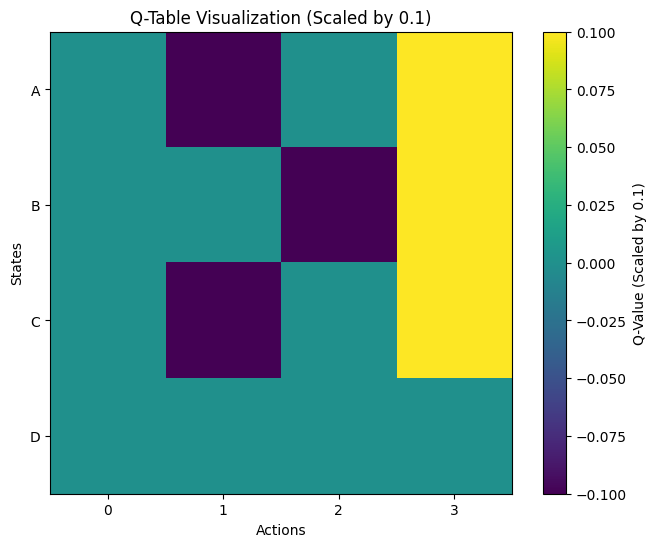

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# تنظیم پارامترها
gamma = 0.8  # ضریب تخفیف
alpha = 0.1  # نرخ یادگیری
episodes = 1000  # تعداد قسمت‌های آموزشی

# تعریف محیط
states = ['A', 'B', 'C', 'D']  # حالات ممکن
actions = [0, 1, 2, 3]  # اقدامات ممکن

# ماتریس پاداش
rewards = np.array([
    [0, -10, 0, 10],
    [-10, 0, -10, 10],
    [0, -10, 0, 10],
    [10, 10, 10, 100],
])

# ماتریس Q
q_table = np.zeros_like(rewards)

# Q-Learning
for _ in range(episodes):
    current_state = np.random.randint(0, len(states))  # انتخاب حالت اولیه تصادفی

    while current_state != 3:  # ادامه تا رسیدن به هدف (حالت D)
        action = np.random.choice(actions)  # انتخاب اقدام به طور تصادفی

        next_state = action
        reward = rewards[current_state, action]

        # بروزرسانی Q-مقدار
        q_table[current_state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[current_state, action]
        )

        current_state = next_state

# کاهش مقادیر Q-Table با ضریب 0.1
scaled_q_table = q_table * 0.1

# رسم نمودار Q-Table
plt.figure(figsize=(8, 6))
plt.imshow(scaled_q_table, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Q-Value (Scaled by 0.1)')
plt.xticks(ticks=np.arange(len(actions)), labels=actions)
plt.yticks(ticks=np.arange(len(states)), labels=states)
plt.xlabel('Actions')
plt.ylabel('States')
plt.title('Q-Table Visualization (Scaled by 0.1)')
plt.show()
